# Training on the NVD/OSV Dataset

## using labeled.csv

---

Data Loading & Preparation

In [1]:
#import cudf
#print(cudf.Series([1, 2, 3]))

import glob
import os
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd


/home/jaket/miniconda3/envs/data-mining/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("dngchnhtrn/nvd-cve-reports-and-affected-libraries")

print("Path to dataset files:", path)

print(os.listdir(path))

# Load labeled.csv dataset
def load_labeled_data() -> pd.DataFrame:
    df = pd.read_csv(os.path.join(path, "labeled.csv"))
    # Parse target column (space-separated library IDs)
    library_ids_list = []
    for x in df['target']:

        if pd.notna(x):
            parsed_ids = []

            for i in str(x).split():
                parsed_ids.append(int(i))
            library_ids_list.append(parsed_ids)

        else:
            library_ids_list.append([])

    df['library_ids'] = library_ids_list

    # Extract primary library (first in list)
    primary_library_list = []

    for x in df['library_ids']:
        if len(x) > 0:
            primary_library_list.append(x[0])
        else:
            primary_library_list.append(-1)

    df['primary_library'] = primary_library_list

    # Count affected libraries
    num_libraries_list = []
    for x in df['library_ids']:
        num_libraries_list.append(len(x))
    df['num_libraries'] = num_libraries_list

    return df

# Load data
df = load_labeled_data()

unique_labels = sorted(df['primary_library'].unique())
label_map = {label: i+1 for i, label in enumerate(unique_labels)}
df['label'] = df['primary_library'].map(label_map)

df['text'] = df['text'].fillna('')
print("Length with duplicates", len(df))
df = df.drop_duplicates(["text"]).reset_index(drop=True)
print(f"Length without duplicates {len(df)} CVE records")
print(f"Unique primary libraries: {df['primary_library'].nunique()}")
print(f"\nSample record:")
print(df.iloc[1])

Path to dataset files: /home/jaket/.cache/kagglehub/datasets/dngchnhtrn/nvd-cve-reports-and-affected-libraries/versions/2
['nvd.csv', 'osv.csv', 'labeled.csv']
Length with duplicates 159810
Length without duplicates 45813 CVE records
Unique primary libraries: 10520

Sample record:
Unnamed: 0                                                         1
text               documenttemplate package zope attacker dtmldoc...
target                                                             0
library_ids                                                      [0]
primary_library                                                    0
num_libraries                                                      1
label                                                              1
Name: 1, dtype: object


In [8]:
# Train/test split
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

print("Num training: ", len(X_train))
print("Num test: ", len(X_test))

Num training:  36650
Num test:  9163


---

Train TF-IDF Vectorizer

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# Initialize vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,           # 5000-dimensional vectors
    ngram_range=(1, 2),          # Unigrams + bigrams
    min_df=2,                    # Ignore rare terms
    max_df=0.8,                  # Ignore very common terms
    sublinear_tf=True,           # Log scaling
    strip_accents='unicode'
)

# Fit on all text
print("Training TF-IDF vectorizer...")
X_tfidf = vectorizer.fit_transform(X_train)

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Sparsity: {(1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])):.2%}")

# Save vectorizer
joblib.dump(vectorizer, 'models/tfidf_vectorizer.pkl')
print("Saved vectorizer to models/tfidf_vectorizer.pkl")

Training TF-IDF vectorizer...
TF-IDF matrix shape: (36650, 5000)
Vocabulary size: 5000
Sparsity: 98.93%
Saved vectorizer to models/tfidf_vectorizer.pkl


In [5]:
# T-SNE visualization
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
# Sample subset for visualization
sample_size = 1000
if len(df) > sample_size:
    sample_indices = df.sample(sample_size, random_state=42).index
    X_sample = X_tfidf[sample_indices]
    y_sample = df.loc[sample_indices, 'primary_library']
else:
    X_sample = X_tfidf
    y_sample = df['primary_library']
print("Running t-SNE on sample...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample.toarray())
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='tab20', alpha=0.7)
plt.colorbar(scatter, label='Primary Library ID')
plt.title('t-SNE Visualization of CVE Text Features')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
print("Saved t-SNE visualization to tsne_visualization.png")
plt.show()

IndexError: index (45782) out of range

---

Train XGBoost

In [6]:
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)),
    ('xgb',   XGBClassifier(n_estimators=100, eval_metric='logloss', tree_method='hist'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [   0    1    2 ... 9082 9083 9084], got [    0     1     3 ... 22173 22175 22180]

---

Evaluate Clustering Quality

Silhouette Score: 0.032

Cluster Distribution:
cluster
0    41034
1    17559
2    19243
3    64621
4    17353
Name: count, dtype: int64

Percentages:
cluster
0    25.68
1    10.99
2    12.04
3    40.44
4    10.86
Name: count, dtype: float64
Saved cluster distribution plot to cluster_distribution.png


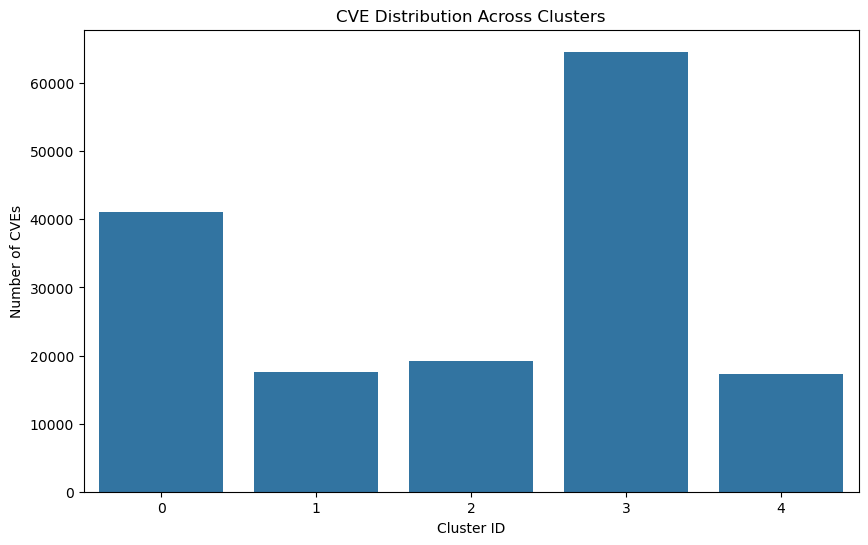

In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import cuml.accel

# Calculate silhouette score
silhouette = silhouette_score(X_sample, kmeans.predict(X_sample))
print(f"Silhouette Score: {silhouette:.3f}")

# Cluster distribution
cluster_counts = df['cluster'].value_counts().sort_index()
print("\nCluster Distribution:")
print(cluster_counts)
print(f"\nPercentages:")
print((cluster_counts / len(df) * 100).round(2))

# Visualize distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.xlabel('Cluster ID')
plt.ylabel('Number of CVEs')
plt.title('CVE Distribution Across Clusters')
plt.savefig('cluster_distribution.png')
print("Saved cluster distribution plot to cluster_distribution.png")

---

Analyze Cluster Characteristics

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Extract top terms for a cluster
def analyze_cluster(cluster_id, df, n_top_terms=10):


    cluster_texts = df[df['cluster'] == cluster_id]['text'].tolist()

    # Extract top terms
    count_vec = CountVectorizer(max_features=n_top_terms, ngram_range=(1, 2))
    count_vec.fit(cluster_texts)
    top_terms = count_vec.get_feature_names_out()

    # Get most common libraries in this cluster
    cluster_libs = df[df['cluster'] == cluster_id]['primary_library'].value_counts().head(5)

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*60}")
    print(f"Size: {len(cluster_texts):,} CVEs ({len(cluster_texts)/len(df)*100:.1f}%)")
    print(f"\nTop Terms: {', '.join(top_terms)}")
    print(f"\nTop Libraries:")

    for lib_id, count in cluster_libs.items():
        print(f"  Library {lib_id}: {count} CVEs")

# Analyze all clusters
for cluster_id in range(5):
    analyze_cluster(cluster_id, df)


CLUSTER 0
Size: 41,034 CVEs (25.7%)

Top Terms: advisories, announce, com, debian, html, lists, opensuse, org, security, www

Top Libraries:
  Library 678: 2859 CVEs
  Library 3280: 2043 CVEs
  Library 3944: 1069 CVEs
  Library 3650: 887 CVEs
  Library 981: 830 CVEs

CLUSTER 1
Size: 17,559 CVEs (11.0%)

Top Terms: git, git kernel, kernel, kernel org, linux, linux vulnerability, org, org stable, stable, vulnerability

Top Libraries:
  Library 3650: 17356 CVEs
  Library 3280: 100 CVEs
  Library 3680: 35 CVEs
  Library 72: 24 CVEs
  Library 3651: 19 CVEs

CLUSTER 2
Size: 19,243 CVEs (12.0%)

Top Terms: announce, com, fedoraproject, fedoraproject org, lists, lists fedoraproject, message, org, package, security

Top Libraries:
  Library 4651: 778 CVEs
  Library 5543: 742 CVEs
  Library 13654: 550 CVEs
  Library 13085: 513 CVEs
  Library 7692: 496 CVEs

CLUSTER 3
Size: 64,621 CVEs (40.4%)

Top Terms: apple, com, github, github com, html, intel, org, qualcomm, security, www

Top Libraries:
 

---

Implement Risk Scoring

In [ ]:
# !!!!! May need to be implemented another way.


# Create mock CVSS scores (in production, fetch from NVD)
np.random.seed(42)
df['cvss_score'] = np.random.uniform(0, 10, len(df))

# Define library criticality (simplified)
library_criticality = {
    0: 0.6,   # Zope - Medium
    1: 0.8,   # Apache Tomcat - High
    4: 1.0,   # OpenSSH - Critical
    66: 0.8,  # Apache HTTP - High
    11: 1.0,  # Linux Kernel - Critical
    # Add more...
}

# Calculate risk score for a CVE
def calculate_risk_score(row):

    # Cluster risk weights (based on analysis)
    cluster_weights = {
        0: 0.9,  # Buffer overflow - high risk
        1: 0.7,  # XSS - medium-high risk
        2: 0.95, # Auth bypass - critical
        3: 0.6,  # DoS - medium risk
        4: 0.8   # Path traversal - high risk
    }

    # CVSS component (35% weight)
    cvss_component = (row['cvss_score'] / 10) * 35

    # Cluster component (20% weight)
    cluster_component = cluster_weights.get(row['cluster'], 0.7) * 20

    # Library component (25% weight)
    if row['primary_library'] in library_criticality:
        lib_score = library_criticality[row['primary_library']]
    else:
        lib_score = 0.5  # Default medium criticality

    # Boost if multiple libraries affected
    lib_breadth = min(row['num_libraries'] / 5, 1.0) * 0.3
    library_component = (lib_score * 0.7 + lib_breadth) * 25

    # Combine (out of 80, leaving 20% for other factors)
    total = cvss_component + cluster_component + library_component

    return min(total, 100)

# Calculate risk scores
print("Calculating risk scores...")
df['risk_score'] = df.apply(calculate_risk_score, axis=1)

# Assign priority labels
def score_to_priority(score):
    if score >= 80:
        return 'CRITICAL'
    elif score >= 60:
        return 'HIGH'
    elif score >= 40:
        return 'MEDIUM'
    else:
        return 'LOW'

df['priority'] = df['risk_score'].apply(score_to_priority)

print("\nRisk Score Distribution:")
print(df['risk_score'].describe())
print("\nPriority Distribution:")
print(df['priority'].value_counts())

Calculating risk scores...

Risk Score Distribution:
count    159810.000000
mean         46.599698
std          10.915453
min          22.250230
25%          37.819733
50%          46.615099
75%          55.382412
max          74.345398
Name: risk_score, dtype: float64

Priority Distribution:
priority
MEDIUM    89085
LOW       49904
HIGH      20821
Name: count, dtype: int64


---

Save Dataset

In [ ]:
# Save dataset with predictions
output_df = df[['target', 'cluster', 'risk_score', 'priority']]
output_df.to_csv('labeled_with_predictions.csv', index=False, sep='|')

print(f"Saved enriched dataset to labeled_with_predictions.csv")
print(f"Total records: {len(output_df):,}")

# Create summary statistics
summary = {
    'total_cves': len(df),
    'total_libraries': df['target'].nunique(),
    'cluster_distribution': df['cluster'].value_counts().to_dict(),
    'priority_distribution': df['priority'].value_counts().to_dict(),
    'avg_risk_score': float(df['risk_score'].mean()),
    'critical_cves': len(df[df['priority'] == 'CRITICAL'])
}

import json
with open('dataset_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\nDataset Summary:")
print(json.dumps(summary, indent=2))

Saved enriched dataset to labeled_with_predictions.csv
Total records: 159,810

Dataset Summary:
{
  "total_cves": 159810,
  "total_libraries": 13795,
  "cluster_distribution": {
    "3": 64621,
    "0": 41034,
    "2": 19243,
    "1": 17559,
    "4": 17353
  },
  "priority_distribution": {
    "MEDIUM": 89085,
    "LOW": 49904,
    "HIGH": 20821
  },
  "avg_risk_score": 46.59969765740509,
  "critical_cves": 0
}
